# SPX implied-volatility surface construction

This notebook examines the calibrated SPX surface for 1 September 2023.

The construction uses six expiry pillars, constrained call-price splines,
and linear interpolation of normalized call prices between expiries.

The normalized coordinates are

$$
z = \frac{K}{F(T)},
\qquad
c(z,T) = \frac{C(K,T)}{D(T)F(T)}.
$$

Between neighbouring expiries,

$$
c(z,T) = (1-\alpha)c(z,T_i) + \alpha c(z,T_{i+1}),
\qquad
\alpha = \frac{T-T_i}{T_{i+1}-T_i}.
$$

A convex combination preserves the decreasing and convex shape of the
expiry curves. Calendar ordering is checked over every cubic interval
within the supported domain.

The notebook loads saved calibration outputs. Set `REBUILD = True` in
the next cell when the inputs or calibration configuration change.


In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly
import plotly.graph_objects as go
import plotly.io as pio

from IPython.display import Image, display
from plotly.colors import qualitative
from plotly.subplots import make_subplots


PROJECT_ROOT = next(
    (
        directory
        for directory in (Path.cwd(), *Path.cwd().parents)
        if (directory / "src" / "vol_surface.py").is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Open this notebook inside the local-vol-spx repository."
    )

SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

from vol_surface import NormalizedCallSurface


CONFIG_PATH = PROJECT_ROOT / "config" / "surface_2023-09-01.json"
config = json.loads(CONFIG_PATH.read_text())

DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "surfaces"
    / config["run_name"]
)
DIAGNOSTIC_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "surface_diagnostics"
    / config["run_name"]
)
OUTPUT_DIR = (
    PROJECT_ROOT / "outputs" / "notebooks" / config["run_name"]
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pio.renderers.default = "vscode"
pio.templates.default = "plotly_white"
pd.set_option("display.float_format", "{:.8g}".format)

REBUILD = False

if REBUILD:
    subprocess.run(
        [
            sys.executable,
            str(PROJECT_ROOT / "scripts" / "build_surface.py"),
            "--config",
            str(CONFIG_PATH),
        ],
        cwd=PROJECT_ROOT,
        env={
            **os.environ,
            "PYTHONPATH": str(SOURCE_DIR),
        },
        check=True,
    )

print("Python:", sys.version.split()[0])
print("Kernel environment:", Path(sys.prefix).name)
print("Plotly:", plotly.__version__)

Python: 3.11.15
Kernel environment: volspx
Plotly: 5.24.1


## Calibration coverage and assumptions

The observed quotes and the generated surface grid serve different purposes.

- Observed quotes determine the fitted expiry models.
- Intermediate maturities and plotting points are evaluations of those models.

The data provider remains unconfirmed. PM settlement is inferred from
the selected expiry dates, and discounting uses a Treasury yield proxy.
These assumptions are retained in the calibration audit.

In [2]:
surface = NormalizedCallSurface.load(
    DATA_DIR / "call_surface.json"
)
grid = pd.read_csv(DATA_DIR / "interpolated_surface.csv")
expiry_summary = pd.read_csv(
    DIAGNOSTIC_DIR / "expiry_summary.csv"
).sort_values("days").reset_index(drop=True)

run_audit = json.loads(
    (DIAGNOSTIC_DIR / "run_audit.json").read_text()
)

overview = pd.Series(
    {
        "Valuation date": config["quote_date"],
        "Expiry pillars": len(surface.splines),
        "Observed quotes fitted": int(expiry_summary["quotes"].sum()),
        "Generated evaluation maturities": grid["maturity_years"].nunique(),
        "Generated surface points": len(grid),
        "Minimum maturity, days": 365.0 * surface.maturities[0],
        "Maximum maturity, days": 365.0 * surface.maturities[-1],
        "Minimum forward log-moneyness": surface.min_log_moneyness,
        "Maximum forward log-moneyness": surface.max_log_moneyness,
        "Data provider": run_audit.get("data_provider", "unconfirmed"),
        "Settlement verification": config["settlement"][
            "verification_status"
        ],
        "Discounting": "Treasury yield proxy",
    },
    name="Value",
).to_frame()

display(overview)

display(
    expiry_summary[
        [
            "expiry",
            "days",
            "raw_rows",
            "parity_pairs",
            "quotes",
            "forward",
            "discount_factor",
            "rms_half_spreads",
            "outside_bands",
            "min_curvature",
        ]
    ]
)

,Value
Valuation date,2023-09-01
Expiry pillars,6
Observed quotes fitted,723
Generated evaluation maturities,45
Generated surface points,9045
"Minimum maturity, days",21
"Maximum maturity, days",60
Minimum forward log-moneyness,-0.09
Maximum forward log-moneyness,0.09
Data provider,unconfirmed


,expiry,days,raw_rows,parity_pairs,quotes,forward,discount_factor,rms_half_spreads,outside_bands,min_curvature
0,2023-09-22,21,186,52,127,4526.1779,0.99687763,0.82193773,25,9.999999e-09
1,2023-09-29,28,373,54,170,4529.8952,0.99583901,0.77027354,22,1e-08
2,2023-10-06,35,176,52,120,4534.1748,0.99479528,0.63511539,11,3.1123974e-05
3,2023-10-13,42,115,32,78,4537.9798,0.99374721,0.77000014,16,2.6675402e-06
4,2023-10-27,56,79,26,49,4547.1288,0.99164401,0.54209865,4,0.00011180085
5,2023-10-31,60,336,54,179,4548.0537,0.99104137,0.64986533,27,2.075582e-05


## Price adjustments relative to quote uncertainty

For each observed strike, define the normalized fitting residual

$$
r_i =
\frac{C_{\mathrm{fit},i}-C_{\mathrm{mid},i}}
     {\text{original quote half-width}_i}.
$$

The original bid–ask interval corresponds to $-1 \leq r_i \leq 1$.

The calibration allows documented band relaxation when required.
The plot shows the size and location of those adjustments.

In [3]:
fit_figure = go.Figure()

for row, model in zip(
    expiry_summary.itertuples(index=False),
    surface.splines,
):
    quotes = pd.read_csv(
        DATA_DIR / str(row.expiry) / "quotes.csv"
    )

    strikes = quotes["strike"].to_numpy()
    residuals = (
        model.price(strikes)
        - quotes["call_mid"].to_numpy()
    ) / quotes["call_half_width"].to_numpy()

    log_moneyness = np.log(strikes / model.pricer.forward)

    fit_figure.add_trace(
        go.Scatter(
            x=log_moneyness.tolist(),
            y=residuals.tolist(),
            mode="markers",
            name=f"{row.expiry} ({row.days:.0f} days)",
            customdata=strikes.tolist(),
            hovertemplate=(
                "Log-moneyness: %{x:.4f}<br>"
                "Strike: %{customdata:.2f}<br>"
                "Residual: %{y:.3f} half-spreads"
                "<extra>%{fullData.name}</extra>"
            ),
        )
    )

fit_figure.add_hrect(
    y0=-1.0,
    y1=1.0,
    fillcolor="lightgrey",
    opacity=0.35,
    line_width=0,
    layer="below",
)
fit_figure.add_hline(
    y=0.0,
    line_color="black",
    line_width=1,
)
fit_figure.update_layout(
    title="Calibration adjustments relative to original quote bands",
    xaxis_title="Forward log-moneyness",
    yaxis_title="Price residual / original half-spread",
    height=500,
    legend_title_text="Expiry",
)
fit_figure.show()

## Calendar ordering and derivative diagnostics

At fixed forward moneyness, normalized call prices must be
non-decreasing with maturity under the stated carry assumptions.

For adjacent expiry curves, the calendar check examines the minimum of

$$
c(z,T_{i+1})-c(z,T_i)
$$

over the entire supported domain.

The check evaluates interval endpoints and interior stationary points
of the cubic price differences. Its tolerance is expressed in
normalized call-price units.

The repricing error below measures Black implied-volatility inversion.
Independent local-volatility pricing validation is a subsequent step.

In [4]:
calendar_checks = pd.DataFrame(surface.calendar_checks())
display(calendar_checks)

diagnostics = pd.Series(
    {
        "All continuous calendar checks passed": bool(
            calendar_checks["passed"].all()
        ),
        "Cubic intervals checked": int(
            calendar_checks["intervals_checked"].sum()
        ),
        "Calendar tolerance, normalized price": surface.calendar_tolerance,
        "Minimum normalized strike curvature": grid[
            "normalized_strike_curvature"
        ].min(),
        "Minimum normalized maturity derivative": grid[
            "normalized_time_derivative_right"
        ].min(),
        "Negative strike-curvature grid points": int(
            (grid["normalized_strike_curvature"] < 0.0).sum()
        ),
        "Negative maturity-derivative grid points": int(
            (grid["normalized_time_derivative_right"] < 0.0).sum()
        ),
        "Maximum IV repricing error, index points": grid[
            "iv_repricing_error"
        ].abs().max(),
    },
    name="Value",
).to_frame()

display(diagnostics)

,intervals_checked,minimum_normalized_call_change,log_moneyness_at_minimum,earlier_days,later_days,passed
0,55,1.2292809e-05,0.09,21,28,True
1,55,2.4592214e-05,0.09,28,35,True
2,55,4.5659184e-05,0.09,35,42,True
3,57,0.00010737507,0.09,42,56,True
4,57,3.7410049e-05,0.09,56,60,True


,Value
All continuous calendar checks passed,True
Cubic intervals checked,279
"Calendar tolerance, normalized price",1e-12
Minimum normalized strike curvature,4.5403546e-05
Minimum normalized maturity derivative,0.00064098219
Negative strike-curvature grid points,0
Negative maturity-derivative grid points,0
"Maximum IV repricing error, index points",1.6720492e-10


## Expiry smiles and total variance

Total implied variance is

$$
w(y,T)=\sigma_{\mathrm{imp}}(y,T)^2T,
\qquad
y=\log(K/F(T)).
$$

Implied-volatility curves can cross while total variance remains
ordered by maturity. Inspect both panels when assessing the term structure.

In [5]:
smile_figure = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.12,
    subplot_titles=("Implied volatility", "Total implied variance"),
)

for index, model in enumerate(surface.splines):
    time = model.pricer.maturity
    selected = grid.loc[
        np.isclose(
            grid["maturity_years"],
            time,
            rtol=0.0,
            atol=1e-14,
        )
    ].sort_values("log_moneyness")

    label = f"{365.0 * time:.0f} days"
    color = qualitative.Plotly[index % len(qualitative.Plotly)]

    smile_figure.add_trace(
        go.Scatter(
            x=selected["log_moneyness"].tolist(),
            y=(100.0 * selected["implied_volatility"]).tolist(),
            mode="lines",
            name=label,
            legendgroup=label,
            line={"color": color},
        ),
        row=1,
        col=1,
    )
    smile_figure.add_trace(
        go.Scatter(
            x=selected["log_moneyness"].tolist(),
            y=selected["total_variance"].tolist(),
            mode="lines",
            name=label,
            legendgroup=label,
            showlegend=False,
            line={"color": color},
        ),
        row=2,
        col=1,
    )

smile_figure.update_yaxes(
    title_text="Implied volatility (%)", row=1, col=1
)
smile_figure.update_yaxes(
    title_text="Total variance", row=2, col=1
)
smile_figure.update_xaxes(
    title_text="Forward log-moneyness", row=2, col=1
)
smile_figure.update_layout(
    height=750,
    title="Calibrated expiry pillars",
    legend={"groupclick": "togglegroup"},
)
smile_figure.show()

## Interactive interpolated surface

Rotate the surface to inspect its strike and maturity structure.
Hover over a point to see its implied volatility, strike, and call price.

The surface includes intermediate maturities generated by the
normalized call-price interpolation.

In [6]:
iv_matrix = (
    grid.pivot(
        index="maturity_years",
        columns="log_moneyness",
        values="implied_volatility",
    )
    .sort_index()
    .sort_index(axis=1)
)

strike_matrix = grid.pivot(
    index="maturity_years",
    columns="log_moneyness",
    values="strike",
).reindex(
    index=iv_matrix.index,
    columns=iv_matrix.columns,
)

price_matrix = grid.pivot(
    index="maturity_years",
    columns="log_moneyness",
    values="call_price",
).reindex(
    index=iv_matrix.index,
    columns=iv_matrix.columns,
)

hover_data = np.stack(
    [
        strike_matrix.to_numpy(),
        price_matrix.to_numpy(),
    ],
    axis=-1,
)

surface_figure = go.Figure(
    go.Surface(
        x=iv_matrix.columns.to_numpy().tolist(),
        y=(365.0 * iv_matrix.index.to_numpy()).tolist(),
        z=(100.0 * iv_matrix.to_numpy()).tolist(),
        customdata=hover_data.tolist(),
        colorscale="Viridis",
        colorbar={"title": "IV (%)"},
        hovertemplate=(
            "Log-moneyness: %{x:.4f}<br>"
            "Maturity: %{y:.2f} days<br>"
            "IV: %{z:.4f}%<br>"
            "Strike: %{customdata[0]:.2f}<br>"
            "Call price: %{customdata[1]:.4f}"
            "<extra></extra>"
        ),
    )
)

surface_figure.update_layout(
    title=f"SPX implied-volatility surface: {config['quote_date']}",
    height=700,
    scene={
        "xaxis_title": "Forward log-moneyness",
        "yaxis_title": "Days to model fixing",
        "zaxis_title": "Implied volatility (%)",
        "camera": {"eye": {"x": 1.5, "y": -1.5, "z": 1.0}},
    },
    margin={"l": 0, "r": 0, "b": 0, "t": 60},
)

surface_figure.show()

html_path = OUTPUT_DIR / "01_iv_surface.html"
surface_figure.write_html(
    html_path,
    include_plotlyjs=True,
    full_html=True,
)

print("Standalone interactive figure:", html_path)

Standalone interactive figure: /Users/pranayvij/GitHub/local-vol-spx/outputs/notebooks/spx_2023-09-01_pilot/01_iv_surface.html


## Query an intermediate maturity

Change `QUERY_DAYS` and `QUERY_LOG_MONEYNESS`, then rerun the next cell.

These queries evaluate the saved model directly. The requested
maturity does not need to appear in the saved plotting grid.

The supported maturity and moneyness bounds are shown in the overview.

In [7]:
QUERY_DAYS = 40.0
QUERY_LOG_MONEYNESS = np.array([-0.05, 0.0, 0.05])

query_time = QUERY_DAYS / 365.0
query_forward = surface.forward(query_time)
query_discount = surface.discount_factor(query_time)
query_strikes = query_forward * np.exp(QUERY_LOG_MONEYNESS)

query_volatility = surface.implied_volatility(
    query_strikes,
    query_time,
)

query_results = pd.DataFrame(
    {
        "maturity_days": QUERY_DAYS,
        "log_moneyness": QUERY_LOG_MONEYNESS,
        "strike": query_strikes,
        "call_price": surface.call_price(
            query_strikes, query_time
        ),
        "implied_volatility_pct": 100.0 * query_volatility,
        "total_variance": query_volatility**2 * query_time,
    }
)

print(f"Forward:         {query_forward:.6f}")
print(f"Discount factor: {query_discount:.8f}")
display(query_results)

Forward:         4536.892348
Discount factor: 0.99404654


,maturity_days,log_moneyness,strike,call_price,implied_volatility_pct,total_variance
0,40,-0.05,4315.6255,238.28226,15.107514,0.0025012272
1,40,0,4536.8923,66.672661,11.194735,0.0013733928
2,40,0.05,4769.5038,3.6696936,9.6190197,0.0010139785


## Static overview and scope

The static figure below provides a compact overview alongside the
interactive views.

This notebook presents a single-valuation-date pilot. The fitted surface
has bounded strike and maturity support, with no global tail extension.

Maturity derivatives are piecewise constant at fixed normalized strike
and can jump at expiry pillars. The model exposes one-sided derivatives
for subsequent local-volatility analysis.

The next stage is Dupire local-volatility extraction, derivative-stability
assessment, and independent pricing validation.

### Reference

[Gatheral and Jacquier: Arbitrage-free SVI volatility surfaces](https://arxiv.org/abs/1204.0646)

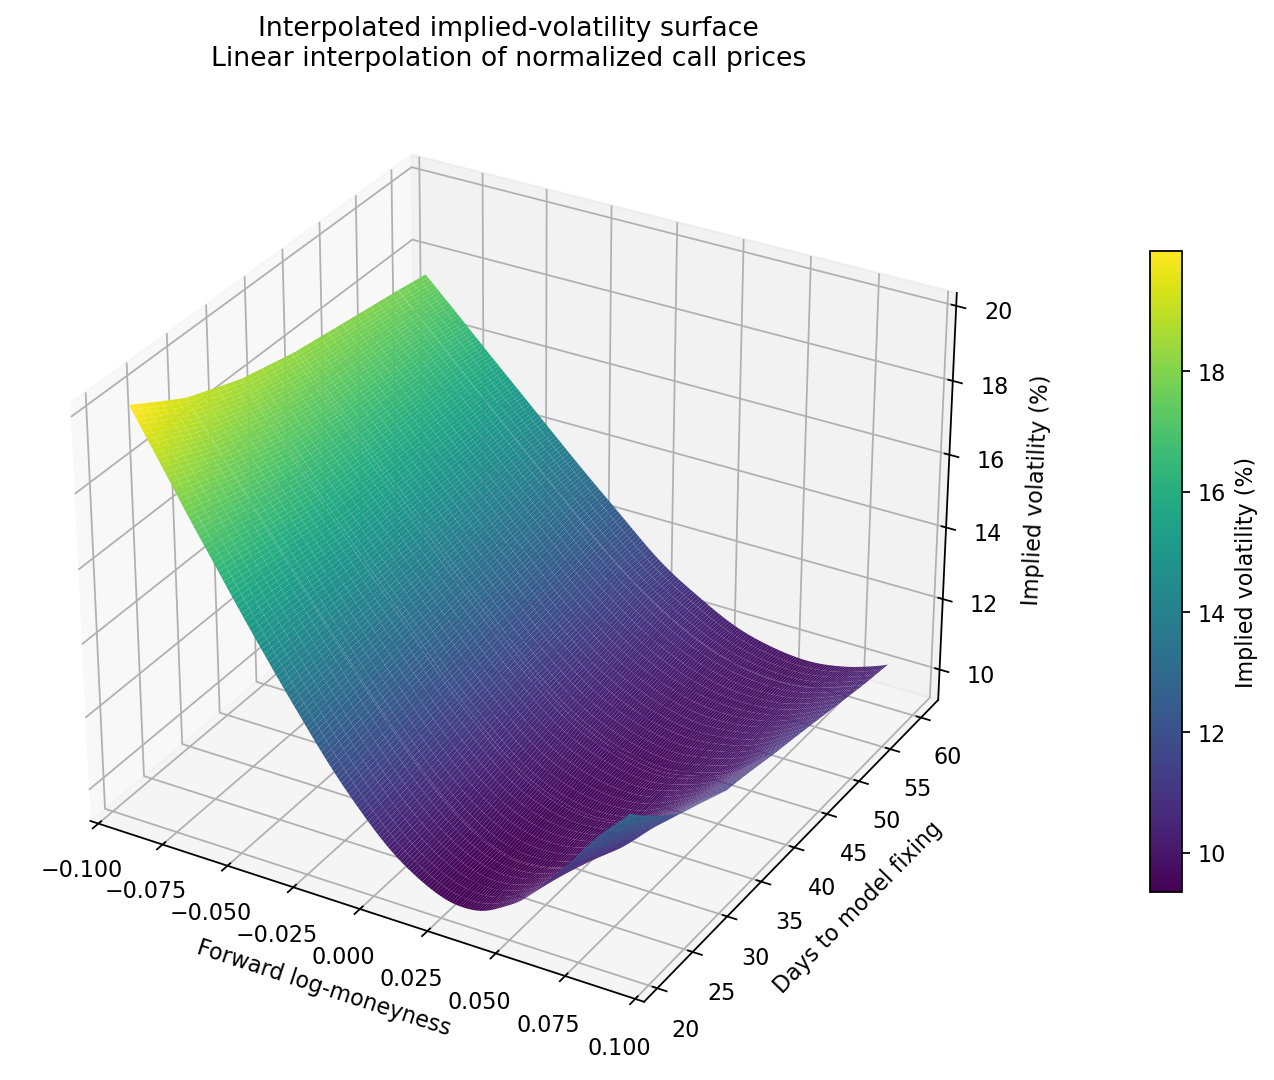

In [8]:
display(
    Image(
        filename=str(DIAGNOSTIC_DIR / "iv_surface.png"),
        width=950,
    )
)